# Stage 01 — Baseline τ search (no ML)

Bayesian optimisation over the 6-dim maintenance interval vector $(\tau_{C1}, \dots, \tau_{C6})$ using Optuna. Each trial runs the deterministic SDG simulator on a stratified subset of printers (one per city) and scores them with the penalised cost / availability objective from `ml_models.lib.objective`.

Top-K trials are re-evaluated on the **full 100-printer fleet** for the final leaderboard. The winner is saved to `results/best_tau.yaml`.

**Tip:** the Optuna study is persisted to a local SQLite file (`results/study.db`), so this notebook is resumable: re-running the search cell continues the same study.

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import yaml

from ml_models.lib.env_runner import default_dates, run_with_tau
from ml_models.lib.objective import scalar_objective
from ml_models.lib.plotting import plot_pareto_cost_availability
from ml_models import PROJECT_ROOT
from sdg.generate import build_printer_city_map, load_configs
from sdg.schema import COMPONENT_IDS

RESULTS_DIR = PROJECT_ROOT / 'ml_models/01_baseline/results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
STUDY_PATH = RESULTS_DIR / 'study.db'
BEST_TAU_PATH = RESULTS_DIR / 'best_tau.yaml'

print('Optuna version:', optuna.__version__)
print('Components:', COMPONENT_IDS)

from ml_models.lib.fast import N_OPTUNA_TRIALS, PARALLEL, banner
banner()


Optuna version: 4.8.0
Components: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')


[fast] mode=FAST · parallel=12 · trials=60/200 · K=20 · epochs=8/2 · ppo_ts=1000/8000 · seeds=(0, 1)


## Search space and printer subset

Per-component log-uniform priors anchored on `digital_twin_hp_metal_jet_s100_spec.md` §6 (operative ranges of $\tau_{nom}$). The trial subset uses one printer per city so each trial costs roughly 15× one-printer simulations — cheap enough for hundreds of trials, diverse enough to capture climate effects.

In [2]:
TAU_RANGES = {
    'C1': (50.0, 2_000.0),
    'C2': (500.0, 20_000.0),
    'C3': (50.0, 500.0),
    'C4': (100.0, 2_000.0),
    'C5': (500.0, 8_000.0),
    'C6': (1_000.0, 20_000.0),
}

components_cfg, couplings_cfg, cities_cfg = load_configs()
printer_city_map = build_printer_city_map(list(cities_cfg['cities']))

seen: set[str] = set()
TRIAL_PRINTER_IDS: list[int] = []
for printer_id, profile in enumerate(printer_city_map):
    name = profile['name']
    if name not in seen:
        seen.add(name)
        TRIAL_PRINTER_IDS.append(printer_id)
DATES = default_dates()

print('Stratified printers (one per city):', TRIAL_PRINTER_IDS)
print('Days per printer:', len(DATES))

Stratified printers (one per city): [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
Days per printer: 3653


In [3]:
def trial_to_tau(trial: optuna.Trial) -> dict[str, float]:
    return {
        component_id: trial.suggest_float(f'tau_{component_id}', low, high, log=True)
        for component_id, (low, high) in TAU_RANGES.items()
    }


def objective(trial: optuna.Trial) -> float:
    tau_vector = trial_to_tau(trial)
    events = run_with_tau(
        tau_vector,
        printer_ids=TRIAL_PRINTER_IDS,
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    for key in ('annual_cost', 'availability', 'preventive_cost', 'corrective_cost', 'deficit'):
        trial.set_user_attr(key, float(score[key]))
    return float(score['value'])

## Run the study

TPE sampler with a fixed seed for reproducibility, MedianPruner kills weak trials early. The study is persisted to SQLite so the cell is **resumable**: re-running it continues from where it left off.

Set `N_TRIALS` to ~30 for a smoke run; ~200–500 for a serious search.

In [4]:
N_TRIALS = N_OPTUNA_TRIALS  # was 200; toggled by FAST_MODE in ml_models.lib.fast
storage_url = f'sqlite:///{STUDY_PATH.as_posix()}'
study = optuna.create_study(
    study_name='baseline_tau',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    storage=storage_url,
    load_if_exists=True,
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=PARALLEL, show_progress_bar=True)
print('Best value:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)

[I 2026-04-25 21:59:35,792] A new study created in RDB with name: baseline_tau


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-25 21:59:54,287] Trial 3 finished with value: 10247878477.142075 and parameters: {'tau_C1': 553.2428316194614, 'tau_C2': 7213.141109287819, 'tau_C3': 55.229454934730505, 'tau_C4': 160.15748433538866, 'tau_C5': 726.5067690710122, 'tau_C6': 3761.672597737981}. Best is trial 1 with value: 10150926198.740759.
[I 2026-04-25 21:59:54,414] Trial 1 finished with value: 10150926198.740759 and parameters: {'tau_C1': 111.9582472143888, 'tau_C2': 17607.401756569972, 'tau_C3': 151.37835445260887, 'tau_C4': 226.25057441290073, 'tau_C5': 1695.5987593742952, 'tau_C6': 1136.4433516764932}. Best is trial 1 with value: 10150926198.740759.


[I 2026-04-25 21:59:55,748] Trial 8 finished with value: 10096815422.666302 and parameters: {'tau_C1': 904.3115783708265, 'tau_C2': 18028.787843041584, 'tau_C3': 357.9252414158332, 'tau_C4': 1413.4916478054558, 'tau_C5': 1017.0116216190802, 'tau_C6': 1562.2993067599414}. Best is trial 8 with value: 10096815422.666302.
[I 2026-04-25 21:59:55,969] Trial 2 finished with value: 10108860315.904736 and parameters: {'tau_C1': 291.26790312763933, 'tau_C2': 6795.394297208293, 'tau_C3': 290.5075277095127, 'tau_C4': 1665.7329543508208, 'tau_C5': 6819.5317161816, 'tau_C6': 1760.404842178365}. Best is trial 8 with value: 10096815422.666302.


[I 2026-04-25 21:59:56,490] Trial 9 finished with value: 10129984507.25431 and parameters: {'tau_C1': 105.329594125665, 'tau_C2': 1854.2530089671243, 'tau_C3': 309.4912672525842, 'tau_C4': 668.3623258667583, 'tau_C5': 3327.4686980463007, 'tau_C6': 4461.29700042416}. Best is trial 8 with value: 10096815422.666302.
[I 2026-04-25 21:59:56,638] Trial 0 finished with value: 10208869443.005749 and parameters: {'tau_C1': 75.58418807002239, 'tau_C2': 2161.697526888338, 'tau_C3': 89.45193033712201, 'tau_C4': 148.84005251201432, 'tau_C5': 852.1158196572184, 'tau_C6': 1262.8276980624325}. Best is trial 8 with value: 10096815422.666302.
[I 2026-04-25 21:59:56,660] Trial 11 finished with value: 10118806481.522036 and parameters: {'tau_C1': 248.2347054118359, 'tau_C2': 8747.02754414522, 'tau_C3': 292.3994060454936, 'tau_C4': 466.91949276979597, 'tau_C5': 763.6260887963581, 'tau_C6': 4627.766018343722}. Best is trial 4 with value: 10090245479.605803.
[I 2026-04-25 21:59:56,663] Trial 4 finished with 

...

[I 2026-04-25 22:01:11,360] Trial 53 finished with value: 10098138535.724064 and parameters: {'tau_C1': 1691.7375348098471, 'tau_C2': 12976.873190132617, 'tau_C3': 255.8585391664554, 'tau_C4': 1999.863159990971, 'tau_C5': 3892.3691484154606, 'tau_C6': 3139.549164555661}. Best is trial 14 with value: 10080527440.186148.


[I 2026-04-25 22:01:12,793] Trial 54 finished with value: 10190163355.871885 and parameters: {'tau_C1': 799.88157858036, 'tau_C2': 8888.42551158092, 'tau_C3': 72.74835940425609, 'tau_C4': 1895.540616970627, 'tau_C5': 3286.287279865225, 'tau_C6': 17040.888698317747}. Best is trial 14 with value: 10080527440.186148.
[I 2026-04-25 22:01:12,810] Trial 51 finished with value: 10191760216.534355 and parameters: {'tau_C1': 1997.5678431154456, 'tau_C2': 1291.7873860963805, 'tau_C3': 65.08202802977124, 'tau_C4': 1948.5124699939465, 'tau_C5': 3991.217114091467, 'tau_C6': 3169.3556057748133}. Best is trial 14 with value: 10080527440.186148.


[I 2026-04-25 22:01:13,763] Trial 55 finished with value: 10101697254.037777 and parameters: {'tau_C1': 773.5383060374742, 'tau_C2': 1248.4862897375197, 'tau_C3': 267.5720568867126, 'tau_C4': 1733.013636527134, 'tau_C5': 3084.9942673597106, 'tau_C6': 2548.065254130949}. Best is trial 14 with value: 10080527440.186148.
[I 2026-04-25 22:01:13,861] Trial 52 finished with value: 10193950196.824528 and parameters: {'tau_C1': 1959.034436187203, 'tau_C2': 8586.199156701696, 'tau_C3': 66.0872688257621, 'tau_C4': 1972.584623676243, 'tau_C5': 4000.3164288082135, 'tau_C6': 2854.0732328483896}. Best is trial 14 with value: 10080527440.186148.


[I 2026-04-25 22:01:14,304] Trial 57 finished with value: 10084086158.77361 and parameters: {'tau_C1': 1978.5591265773987, 'tau_C2': 12866.366105848274, 'tau_C3': 427.66273832593356, 'tau_C4': 1686.502448636027, 'tau_C5': 3496.9585529609876, 'tau_C6': 12450.763907973596}. Best is trial 14 with value: 10080527440.186148.


[I 2026-04-25 22:01:14,846] Trial 58 finished with value: 10082534922.255678 and parameters: {'tau_C1': 1842.172448089721, 'tau_C2': 12931.232903208316, 'tau_C3': 431.8338618894131, 'tau_C4': 1742.760126672479, 'tau_C5': 7212.963696467122, 'tau_C6': 12791.751842636731}. Best is trial 14 with value: 10080527440.186148.
[I 2026-04-25 22:01:14,856] Trial 56 finished with value: 10084861776.8957 and parameters: {'tau_C1': 1957.7291882053653, 'tau_C2': 12299.384410265297, 'tau_C3': 421.45432949300755, 'tau_C4': 1717.3936310912438, 'tau_C5': 7165.390065989306, 'tau_C6': 12686.161578258416}. Best is trial 14 with value: 10080527440.186148.
[I 2026-04-25 22:01:14,886] Trial 59 finished with value: 10094944813.851627 and parameters: {'tau_C1': 1988.092577830546, 'tau_C2': 12425.898463289903, 'tau_C3': 262.3194526582713, 'tau_C4': 1806.5881626330527, 'tau_C5': 7264.511727175343, 'tau_C6': 17359.93727487288}. Best is trial 14 with value: 10080527440.186148.
Best value: 10080527440.186148
Best par

In [5]:
trials_df = study.trials_dataframe()
trials_df = trials_df.dropna(subset=['value']).sort_values('value').reset_index(drop=True)
display_cols = ['number', 'value', 'user_attrs_annual_cost', 'user_attrs_availability']
display_cols += [f'params_tau_{component_id}' for component_id in COMPONENT_IDS]
trials_df.loc[:9, display_cols].round(3)

,number,value,user_attrs_annual_cost,user_attrs_availability,params_tau_C1,params_tau_C2,params_tau_C3,params_tau_C4,params_tau_C5,params_tau_C6
0,14,1.008053e+10,3717116.155,0.042,1832.001,18131.890,490.314,1984.064,3460.656,16456.650
1,13,1.008162e+10,3717546.096,0.042,1948.827,18016.735,468.242,1971.288,3020.001,18404.404
2,58,1.008253e+10,3717326.126,0.042,1842.172,12931.233,431.834,1742.760,7212.964,12791.752
3,21,1.008295e+10,3717281.132,0.042,1885.825,11431.011,463.316,1688.078,6946.497,12681.668
4,57,1.008409e+10,3717971.038,0.042,1978.559,12866.366,427.663,1686.502,3496.959,12450.764
5,20,1.008468e+10,3718211.005,0.042,1939.798,12063.827,470.965,1869.040,7216.282,18330.652
6,56,1.008486e+10,3718270.996,0.042,1957.729,12299.384,421.454,1717.394,7165.390,12686.162
7,18,1.008491e+10,3718285.994,0.042,1991.618,11369.403,497.041,1907.257,7941.854,15129.353
8,19,1.008600e+10,3718460.970,0.041,1889.827,11163.909,485.910,1994.610,7817.871,13040.730
9,15,1.008614e+10,3718270.996,0.041,1659.454,10008.225,469.096,1931.025,7963.400,19945.632


## Re-evaluate top trials on the full 100-printer fleet

The trial subset of 15 printers is fast but biased; re-evaluating the top-K candidates on all 100 printers gives an unbiased final ranking.

In [6]:
TOP_K = 5
fleet_results = []
for _, row in trials_df.head(TOP_K).iterrows():
    tau_vector = {
        component_id: float(row[f'params_tau_{component_id}'])
        for component_id in COMPONENT_IDS
    }
    events = run_with_tau(
        tau_vector,
        printer_ids=range(100),
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    fleet_results.append(
        {
            'trial': int(row['number']),
            'value': float(score['value']),
            'annual_cost': float(score['annual_cost']),
            'availability': float(score['availability']),
            'preventive_cost': float(score['preventive_cost']),
            'corrective_cost': float(score['corrective_cost']),
            **{f'tau_{c}': tau_vector[c] for c in COMPONENT_IDS},
        }
    )
fleet_df = pd.DataFrame(fleet_results).sort_values('value').reset_index(drop=True)
fleet_df

,trial,value,annual_cost,availability,preventive_cost,corrective_cost,tau_C1,tau_C2,tau_C3,tau_C4,tau_C5,tau_C6
0,14,1.009535e+10,3.695824e+06,0.040465,0.0,3.695824e+06,1832.000591,18131.889804,490.313546,1984.064082,3460.655651,16456.649613
1,13,1.009660e+10,3.696310e+06,0.040340,0.0,3.696310e+06,1948.826614,18016.735403,468.241712,1971.288194,3020.001487,18404.403691
2,21,1.009663e+10,3.696153e+06,0.040337,0.0,3.696153e+06,1885.824694,11431.010627,463.316310,1688.078041,6946.497329,12681.668265
3,58,1.009982e+10,3.697652e+06,0.040018,0.0,3.697652e+06,1842.172448,12931.232903,431.833862,1742.760127,7212.963696,12791.751843
4,57,1.010155e+10,3.698252e+06,0.039845,0.0,3.698252e+06,1978.559127,12866.366106,427.662738,1686.502449,3496.958553,12450.763908


In [7]:
winner = fleet_df.iloc[0]
best_tau = {component_id: float(winner[f'tau_{component_id}']) for component_id in COMPONENT_IDS}
payload = {
    'tau_nom_h': best_tau,
    'validated_on': 'full fleet (printer_id 0..99)',
    'penalised_value': float(winner['value']),
    'annual_cost_eur_per_printer_year': float(winner['annual_cost']),
    'availability': float(winner['availability']),
    'preventive_cost_eur_per_printer_year': float(winner['preventive_cost']),
    'corrective_cost_eur_per_printer_year': float(winner['corrective_cost']),
}
with BEST_TAU_PATH.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(payload, handle, sort_keys=False)
print('Wrote:', BEST_TAU_PATH)
print(yaml.safe_dump(payload, sort_keys=False))

Wrote: C:\Users\Sergi\OneDrive\Desktop\Industrial Engineering\Q8\TFG\Coding\hackupc2026\ml_models\01_baseline\results\best_tau.yaml
tau_nom_h:
  C1: 1832.000591403533
  C2: 18131.889804338563
  C3: 490.3135458254983
  C4: 1984.0640817071658
  C5: 3460.655650685876
  C6: 16456.649613381538
validated_on: full fleet (printer_id 0..99)
penalised_value: 10095346310.429783
annual_cost_eur_per_printer_year: 3695824.069258144
availability: 0.040465368957021595
preventive_cost_eur_per_printer_year: 0.0
corrective_cost_eur_per_printer_year: 3695824.069258144



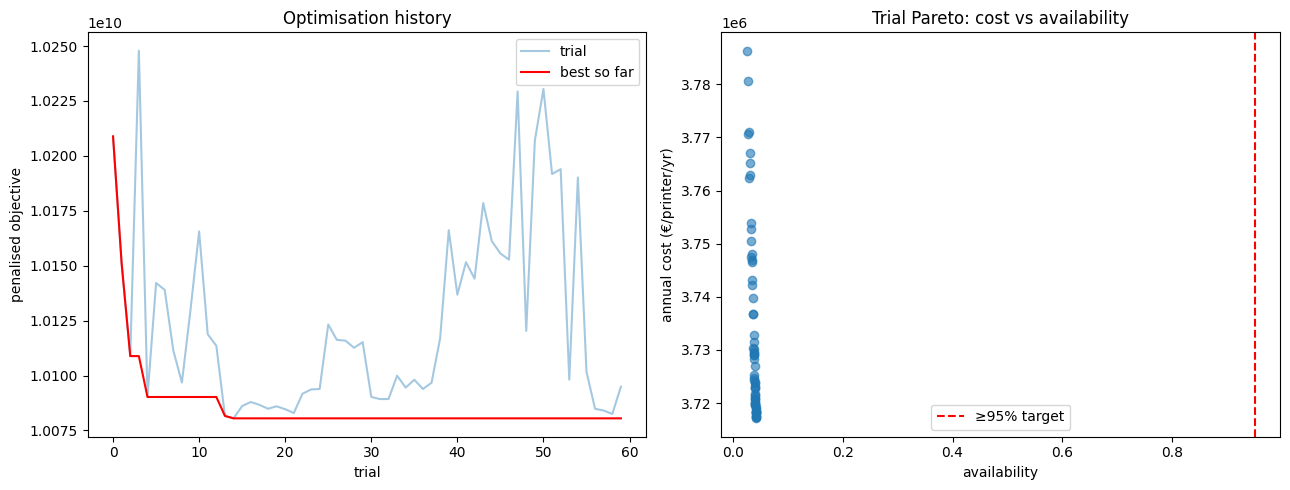

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
history = study.trials_dataframe().dropna(subset=['value'])
axes[0].plot(history['number'], history['value'], alpha=0.4, label='trial')
axes[0].plot(history['number'], history['value'].cummin(), color='red', label='best so far')
axes[0].set_xlabel('trial')
axes[0].set_ylabel('penalised objective')
axes[0].set_title('Optimisation history')
axes[0].legend()

study_df = study.trials_dataframe().dropna(subset=['user_attrs_annual_cost', 'user_attrs_availability'])
study_df = study_df.rename(columns={
    'user_attrs_annual_cost': 'annual_cost',
    'user_attrs_availability': 'availability',
})
plot_pareto_cost_availability(study_df, ax=axes[1])
axes[1].set_title('Trial Pareto: cost vs availability')
plt.tight_layout()
plt.show()

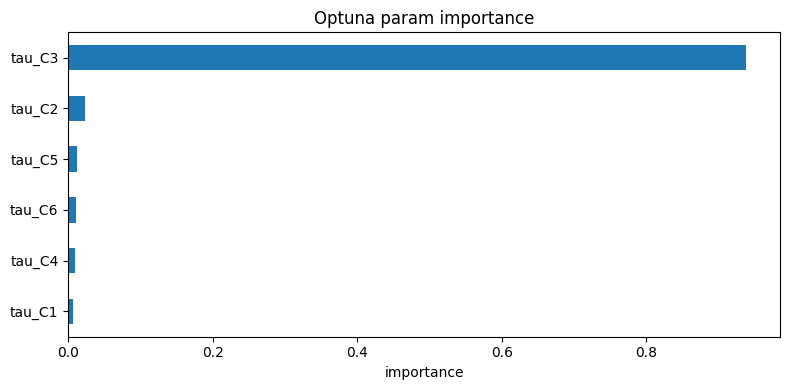

In [9]:
try:
    importance = optuna.importance.get_param_importances(study)
    pd.Series(importance).sort_values().plot(kind='barh', figsize=(8, 4), title='Optuna param importance')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Importance unavailable:', exc)